<a href="https://colab.research.google.com/github/eduardobatistadefreitas-art/nodo-regulator/blob/main/S26Untitled8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Executando dt = 0.01
Timesteps = 10000
E0        : 1.099176527150e-01
Efinal    : 1.099175262230e-01
Erro Abs  : 2.056328e-07
Erro Rel  : 1.870789e-06
Executando dt = 0.005
Timesteps = 20000
E0        : 1.099174629763e-01
Efinal    : 1.099174313529e-01
Erro Abs  : 5.140826e-08
Erro Rel  : 4.676987e-07
Executando dt = 0.001
Timesteps = 100000
E0        : 1.099174022599e-01
Efinal    : 1.099174009968e-01
Erro Abs  : 2.056070e-09
Erro Rel  : 1.870559e-08
Executando dt = 0.0005
Timesteps = 200000
E0        : 1.099174003625e-01
Efinal    : 1.099174000513e-01
Erro Abs  : 5.115388e-10
Erro Rel  : 4.653847e-09


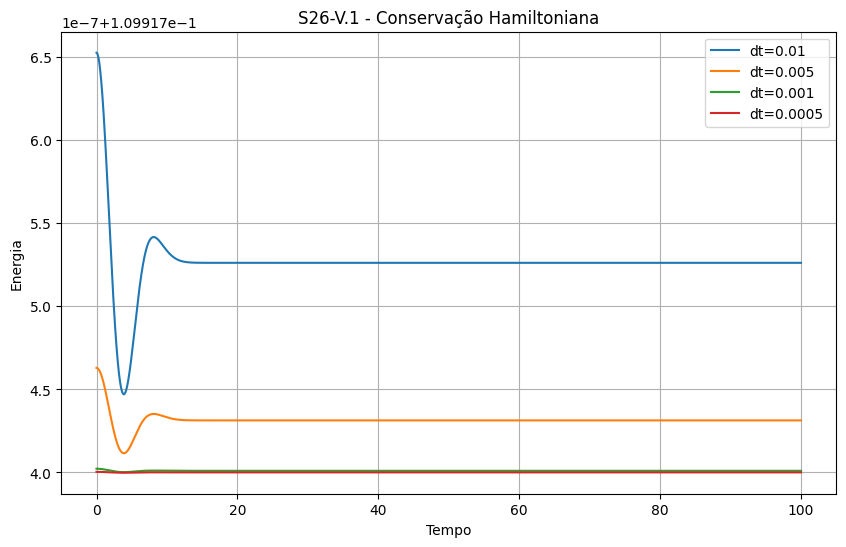


Resumo

dt          ErroAbsMax        ErroRelMax        
1.0e-02     2.056328e-07      1.870789e-06      
5.0e-03     5.140826e-08      4.676987e-07      
1.0e-03     2.056070e-09      1.870559e-08      
5.0e-04     5.115388e-10      4.653847e-09      


In [2]:
resultado_v1 = audit_energy_conservation()

dt = 0.01
Erro RMS final: 0.00012009306671506359
Erro MAX final: 0.0008394569739956781
Erro REL final: 0.001767649192511151
dt = 0.005
Erro RMS final: 5.993153968352286e-05
Erro MAX final: 0.00041857158396879646
Erro REL final: 0.000882132004996431
dt = 0.001
Erro RMS final: 1.1967934280855172e-05
Erro MAX final: 8.352904299607777e-05
Erro REL final: 0.00017615595925927528
dt = 0.0005
Erro RMS final: 5.982819627778321e-06
Erro MAX final: 4.175292807012676e-05
Erro REL final: 8.806108939722578e-05


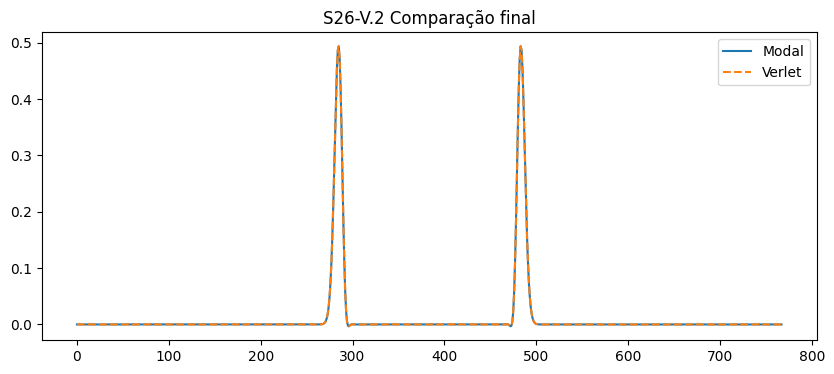

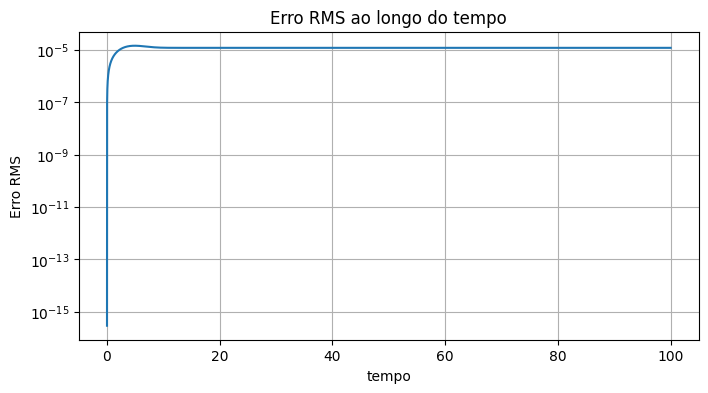


RELATÓRIO S26-V.2
dt=1.0e-02 erro final= 0.001767649192511151
dt=5.0e-03 erro final= 0.000882132004996431
dt=1.0e-03 erro final= 0.00017615595925927528
dt=5.0e-04 erro final= 8.806108939722578e-05


In [3]:
# ================================================================
# IA-1 — S26-V.2
# Auditoria Cruzada:
# Verlet x Solução Modal Analítica
# ================================================================

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt


# ================================================================
# 1. CONSTRUÇÃO DA REDE F1
# ================================================================

def build_F1(n):

    A = np.zeros((n,n))

    for i in range(n):
        A[i,(i+1)%n] = 1.0
        A[i,(i-1)%n] = 1.0

    D = np.diag(np.sum(A,axis=1))

    L = D - A

    return L


# ================================================================
# 2. SOLUÇÃO MODAL ANALÍTICA
# ================================================================

def modal_solution(L, gamma0, times, alpha=1.0):

    eigvals, eigvecs = la.eigh(L)

    eigvals[np.abs(eigvals)<1e-12] = 0

    omega = np.sqrt(alpha*eigvals)

    # projeção inicial
    coeff = eigvecs.T @ gamma0


    solutions=[]

    for t in times:

        phase=np.cos(omega*t)

        gamma = eigvecs @ (coeff*phase)

        solutions.append(gamma)


    return np.array(solutions), eigvals, eigvecs



# ================================================================
# 3. INTEGRAÇÃO VERLET
# ================================================================

def verlet_solution(L, gamma0, times, dt, alpha=1.0):


    total_steps=len(times)-1

    gamma_current=np.copy(gamma0)


    # velocidade inicial zero
    acceleration=-alpha*(L@gamma_current)

    gamma_past = (
        gamma_current
        -0.5*(dt**2)*acceleration
    )


    history=[gamma_current.copy()]


    for step in range(total_steps):

        acceleration=-alpha*(L@gamma_current)


        gamma_future = (
            2*gamma_current
            -gamma_past
            +(dt**2)*acceleration
        )


        gamma_past=np.copy(gamma_current)

        gamma_current=np.copy(gamma_future)


        history.append(gamma_current.copy())


    return np.array(history)



# ================================================================
# 4. MÉTRICAS DE ERRO
# ================================================================

def compare_solutions(reference, numerical):


    diff = numerical-reference


    rms=np.sqrt(
        np.mean(diff**2,axis=1)
    )


    max_error=np.max(
        np.abs(diff),
        axis=1
    )


    relative=rms/(

        np.sqrt(
            np.mean(reference**2,axis=1)
        )
        +1e-15
    )


    return rms,max_error,relative



# ================================================================
# 5. EXECUÇÃO PRINCIPAL
# ================================================================


n=768

alpha=1.0


T=100


dt_values=[
    0.01,
    0.005,
    0.001,
    0.0005
]


# pulso inicial
x=np.arange(n)

mid=n//2


sigma=4.0


gamma0=np.exp(
    -(x-mid)**2/(2*sigma**2)
)



results={}


for dt in dt_values:


    print("="*60)

    print("dt =",dt)


    times=np.arange(
        0,
        T+dt,
        dt
    )


    modal, eigvals, eigvecs = modal_solution(
        build_F1(n),
        gamma0,
        times,
        alpha
    )


    verlet = verlet_solution(
        build_F1(n),
        gamma0,
        times,
        dt,
        alpha
    )


    rms,maxe,rel = compare_solutions(
        modal,
        verlet
    )


    results[dt]={

        "rms":rms,
        "max":maxe,
        "rel":rel

    }


    print(
        "Erro RMS final:",
        rms[-1]
    )

    print(
        "Erro MAX final:",
        maxe[-1]
    )

    print(
        "Erro REL final:",
        rel[-1]
    )



# ================================================================
# 6. GRÁFICOS
# ================================================================


dt=0.001


times=np.arange(
    0,
    T+dt,
    dt
)


modal,_,_=modal_solution(
    build_F1(n),
    gamma0,
    times
)


verlet=verlet_solution(
    build_F1(n),
    gamma0,
    times,
    dt
)



# comparação final

plt.figure(figsize=(10,4))

plt.plot(
    modal[-1],
    label="Modal"
)

plt.plot(
    verlet[-1],
    "--",
    label="Verlet"
)

plt.legend()

plt.title(
    "S26-V.2 Comparação final"
)

plt.show()



# erro temporal

rms,_,_=compare_solutions(
    modal,
    verlet
)


plt.figure(figsize=(8,4))

plt.semilogy(
    times,
    rms
)

plt.xlabel("tempo")

plt.ylabel("Erro RMS")

plt.title(
    "Erro RMS ao longo do tempo"
)

plt.grid()

plt.show()



# ================================================================
# 7. RELATÓRIO FINAL
# ================================================================


print("\n==============================")
print("RELATÓRIO S26-V.2")
print("==============================")

for dt in dt_values:

    print(
        f"dt={dt:.1e}",
        "erro final=",
        results[dt]["rel"][-1]
    )

In [4]:
# ================================================================
# IA-1 — S26-V.2.1
# Auditoria Modal Discreta:
# Verlet x Solução Analítica do Próprio Integrador
# SEM GRÁFICOS
# ================================================================

import numpy as np
import scipy.linalg as la


# ================================================================
# SOLUÇÃO MODAL CONTÍNUA
# ================================================================

def modal_continuous(L, gamma0, times, alpha=1.0):

    eigvals, eigvecs = la.eigh(L)

    eigvals[np.abs(eigvals)<1e-12]=0

    omega=np.sqrt(alpha*eigvals)

    coeff=eigvecs.T@gamma0

    result=[]

    for t in times:

        gamma=eigvecs @ (
            coeff*np.cos(omega*t)
        )

        result.append(gamma)

    return np.array(result)



# ================================================================
# SOLUÇÃO MODAL DISCRETA DO VERLET
# ================================================================

def modal_verlet_discrete(L, gamma0, times, dt, alpha=1.0):


    eigvals,eigvecs=la.eigh(L)

    eigvals[np.abs(eigvals)<1e-12]=0


    omega=np.sqrt(alpha*eigvals)


    # frequência efetiva do Verlet

    omega_num=np.zeros_like(omega)

    mask=omega*dt/2 < 1

    omega_num[mask]=(
        2/dt *
        np.arcsin(
            omega[mask]*dt/2
        )
    )


    coeff=eigvecs.T@gamma0


    result=[]


    for t in times:

        gamma=eigvecs @ (
            coeff*np.cos(omega_num*t)
        )

        result.append(gamma)


    return np.array(result)



# ================================================================
# COMPARADOR
# ================================================================

def error_metrics(reference,numerical):

    diff=numerical-reference

    rms=np.sqrt(
        np.mean(diff**2,axis=1)
    )

    maxerr=np.max(
        np.abs(diff),
        axis=1
    )

    rel=rms/(
        np.sqrt(
            np.mean(reference**2,axis=1)
        )+1e-15
    )

    return rms[-1],maxerr[-1],rel[-1]



# ================================================================
# EXECUÇÃO
# ================================================================


n=768

alpha=1.0

T=100


# mesma condição inicial

x=np.arange(n)

mid=n//2

sigma=4.0

gamma0=np.exp(
    -(x-mid)**2/(2*sigma**2)
)


# Laplaciano

A=np.zeros((n,n))

for i in range(n):

    A[i,(i+1)%n]=1
    A[i,(i-1)%n]=1


D=np.diag(np.sum(A,axis=1))

L=D-A



dt_values=[
    0.01,
    0.005,
    0.001,
    0.0005
]



print("\n================================================")
print("S26-V.2.1 — RESULTADOS")
print("================================================")


for dt in dt_values:


    times=np.arange(
        0,
        T+dt,
        dt
    )


    verlet=verlet_solution(
        L,
        gamma0,
        times,
        dt,
        alpha
    )


    modal_c=modal_continuous(
        L,
        gamma0,
        times,
        alpha
    )


    modal_d=modal_verlet_discrete(
        L,
        gamma0,
        times,
        dt,
        alpha
    )


    ec=error_metrics(
        modal_c,
        verlet
    )


    ed=error_metrics(
        modal_d,
        verlet
    )


    print("\n------------------------------------------------")
    print("dt =",dt)

    print("\nVerlet x Modal Contínuo")

    print(
        "RMS:",
        ec[0]
    )

    print(
        "MAX:",
        ec[1]
    )

    print(
        "REL:",
        ec[2]
    )


    print("\nVerlet x Modal Discreto")

    print(
        "RMS:",
        ed[0]
    )

    print(
        "MAX:",
        ed[1]
    )

    print(
        "REL:",
        ed[2]
    )



print("\n================================================")
print("Fim S26-V.2.1")
print("================================================")


S26-V.2.1 — RESULTADOS

------------------------------------------------
dt = 0.01

Verlet x Modal Contínuo
RMS: 0.00012009306671506359
MAX: 0.0008394569739956781
REL: 0.001767649192511151

Verlet x Modal Discreto
RMS: 0.00011963358377172372
MAX: 0.0008348225640839035
REL: 0.0017608860655798152

------------------------------------------------
dt = 0.005

Verlet x Modal Contínuo
RMS: 5.993153968352286e-05
MAX: 0.00041857158396879646
REL: 0.000882132004996431

Verlet x Modal Discreto
RMS: 5.981674022266423e-05
MAX: 0.0004174129754656031
REL: 0.0008804422723595839

------------------------------------------------
dt = 0.001

Verlet x Modal Contínuo
RMS: 1.1967934280855172e-05
MAX: 8.352904299607777e-05
REL: 0.00017615595925927528

Verlet x Modal Discreto
RMS: 1.1963344586998342e-05
MAX: 8.348269857871848e-05
REL: 0.00017608840358048527

------------------------------------------------
dt = 0.0005

Verlet x Modal Contínuo
RMS: 5.982819627778321e-06
MAX: 4.175292807012676e-05
REL: 8.80610

In [5]:
# ================================================================
# IA-1 — S26-V.2.2
# Auditoria da Ordem Experimental do Verlet
# SEM GRÁFICOS
# ================================================================

import numpy as np
import scipy.linalg as la


def build_laplacian(n):

    A=np.zeros((n,n))

    for i in range(n):
        A[i,(i+1)%n]=1
        A[i,(i-1)%n]=1

    D=np.diag(np.sum(A,axis=1))

    return D-A



def modal_reference(L,gamma0,times,alpha=1.0):

    eigvals,eigvecs=la.eigh(L)

    eigvals[np.abs(eigvals)<1e-12]=0

    omega=np.sqrt(alpha*eigvals)

    coeff=eigvecs.T@gamma0

    result=[]

    for t in times:

        result.append(
            eigvecs @ (coeff*np.cos(omega*t))
        )

    return np.array(result)



def verlet_corrected(L,gamma0,times,dt,alpha=1.0):

    a0=-alpha*(L@gamma0)

    # inicialização corrigida
    gamma_past = gamma0 + 0.5*(dt**2)*a0

    gamma_current=np.copy(gamma0)

    output=[]

    for t in times:

        output.append(
            np.copy(gamma_current)
        )

        acceleration=-alpha*(L@gamma_current)

        gamma_future=(
            2*gamma_current
            -gamma_past
            +(dt**2)*acceleration
        )

        gamma_past=gamma_current
        gamma_current=gamma_future


    return np.array(output)



def rms_global(reference,numerical):

    diff=numerical-reference

    return np.sqrt(
        np.mean(diff**2)
    )



# ================================================================
# EXECUÇÃO
# ================================================================


n=768
alpha=1.0

x=np.arange(n)

mid=n//2

sigma=4.0


gamma0=np.exp(
    -(x-mid)**2/(2*sigma**2)
)


L=build_laplacian(n)


dt_values=[
    0.01,
    0.005,
    0.001,
    0.0005
]


errors=[]


print("\n================================================")
print("S26-V.2.2 — RESULTADOS")
print("================================================")


for dt in dt_values:


    T=100


    times=np.arange(
        0,
        T+dt,
        dt
    )


    ref=modal_reference(
        L,
        gamma0,
        times,
        alpha
    )


    num=verlet_corrected(
        L,
        gamma0,
        times,
        dt,
        alpha
    )


    erro=rms_global(
        ref,
        num
    )


    errors.append(erro)


    print("--------------------------------")
    print("dt =",dt)
    print("Erro RMS global =",erro)



print("\n================================================")
print("ORDEM EXPERIMENTAL")
print("================================================")


for i in range(len(dt_values)-1):

    p=np.log(
        errors[i]/errors[i+1]
    )/np.log(2)


    print(
        "dt",
        dt_values[i],
        "->",
        dt_values[i+1],
        " ordem p = ",
        p
    )


print("\n================================================")
print("Fim S26-V.2.2")
print("================================================")


S26-V.2.2 — RESULTADOS
--------------------------------
dt = 0.01
Erro RMS global = 3.4030786759729614e-07
--------------------------------
dt = 0.005
Erro RMS global = 8.507573160664628e-08
--------------------------------
dt = 0.001
Erro RMS global = 3.4031094893118443e-09
--------------------------------
dt = 0.0005
Erro RMS global = 8.51269270665173e-10

ORDEM EXPERIMENTAL
dt 0.01 -> 0.005  ordem p =  2.00002094766214
dt 0.005 -> 0.001  ordem p =  4.643822179220369
dt 0.001 -> 0.0005  ordem p =  1.9991661106181828

Fim S26-V.2.2


In [6]:
# ================================================================
# IA-1 — S26-V.3
# Auditoria Modal Individual e Conservação Espectral
# SEM GRÁFICOS
# ================================================================

import numpy as np
import scipy.linalg as la


# ================================================================
# MATRIZ RELACIONAL
# ================================================================

def build_laplacian(n):

    A=np.zeros((n,n))

    for i in range(n):
        A[i,(i+1)%n]=1
        A[i,(i-1)%n]=1

    D=np.diag(np.sum(A,axis=1))

    return D-A



# ================================================================
# VERLET MODAL
# ================================================================

def evolve_verlet_mode(omega, q0, dt, steps):

    q_prev = q0 + 0.5*(dt**2)*(-omega**2*q0)

    q=q0

    history=[]

    for _ in range(steps):

        history.append(q)

        q_next=(
            2*q
            -q_prev
            -(dt**2)*omega**2*q
        )

        q_prev=q
        q=q_next


    return np.array(history)



# ================================================================
# ENERGIA MODAL
# ================================================================

def modal_energy(q,dt,omega):

    v=np.gradient(q,dt)

    return (
        0.5*v**2
        +
        0.5*(omega**2)*(q**2)
    )



# ================================================================
# EXECUÇÃO
# ================================================================

n=768

alpha=1.0

dt=0.001

T=100

steps=int(T/dt)



L=build_laplacian(n)


eigvals,eigvecs=la.eigh(L)

eigvals[np.abs(eigvals)<1e-12]=0


omega=np.sqrt(alpha*eigvals)



# modos selecionados

modes=[
    0,
    1,
    10,
    100,
    n//2,
    n-2
]


print("\n================================================")
print("S26-V.3 — RESULTADOS")
print("================================================")


for m in modes:


    w=omega[m]


    print("\n--------------------------------")
    print("Modo:",m)
    print("Lambda:",eigvals[m])
    print("Omega:",w)


    if w < 1e-12:

        print("Modo zero: sem oscilacao.")
        continue


    q=evolve_verlet_mode(
        w,
        1.0,
        dt,
        steps
    )


    tempo=np.arange(
        steps
    )*dt


    referencia=np.cos(w*tempo)


    erro=np.sqrt(
        np.mean(
            (q-referencia)**2
        )
    )


    energia=modal_energy(
        q,
        dt,
        w
    )


    erro_energia=(
        np.max(energia)
        -
        np.min(energia)
    )/(energia[0]+1e-15)



    print(
        "Erro RMS modal:",
        erro
    )


    print(
        "E0:",
        energia[0]
    )


    print(
        "Desvio relativo energia:",
        erro_energia
    )



print("\n================================================")
print("Fim S26-V.3")
print("================================================")


S26-V.3 — RESULTADOS

--------------------------------
Modo: 0
Lambda: 0.0
Omega: 0.0
Modo zero: sem oscilacao.

--------------------------------
Modo: 1
Lambda: 6.69321651976155e-05
Omega: 0.008181208052458725
Erro RMS modal: 5.551869505635075e-10
E0: 3.346608259936773e-05
Desvio relativo energia: 4.081928071625502e-06

--------------------------------
Modo: 10
Lambda: 0.0016730801447029763
Omega: 0.040903302369160566
Erro RMS modal: 8.186187332035453e-11
E0: 0.0008365400727013878
Desvio relativo energia: 1.937092106806214e-05

--------------------------------
Modo: 100
Lambda: 0.1650110071050186
Omega: 0.4062154688155272
Erro RMS modal: 1.1488012861305939e-07
E0: 0.08250550695608834
Desvio relativo energia: 8.642977776855957e-05

--------------------------------
Modo: 384
Lambda: 1.9999999999999998
Omega: 1.414213562373095
Erro RMS modal: 4.808541881505046e-06
E0: 1.0000004999999996
Desvio relativo energia: 6.818063642463187e-05

--------------------------------
Modo: 766
Lambda: 3.

In [7]:
# ================================================================
# IA-1 — S26-V.4
# Auditoria de Dispersão Espectral e Velocidade de Grupo
# SEM GRÁFICOS
# ================================================================

import numpy as np
import scipy.linalg as la


# ================================================================
# CONSTRUÇÃO DO OPERADOR
# ================================================================

def build_laplacian(n):

    A=np.zeros((n,n))

    for i in range(n):
        A[i,(i+1)%n]=1.0
        A[i,(i-1)%n]=1.0

    D=np.diag(np.sum(A,axis=1))

    return D-A



# ================================================================
# EXECUÇÃO
# ================================================================

n=1536
alpha=1.0


L=build_laplacian(n)


eigvals,_=la.eigh(L)

eigvals[np.abs(eigvals)<1e-14]=0


# ================================================================
# RELAÇÃO ESPECTRAL
# ================================================================

# Para cadeia periódica:
# k_m = 2*pi*m/n

modes=np.arange(n)

k=2*np.pi*modes/n


omega_num=np.sqrt(alpha*eigvals)


# somente primeira metade independente
half=n//2


k=k[:half]
omega_num=omega_num[:half]


omega_cont=k


omega_disc=2*np.sqrt(alpha)*np.sin(k/2)



# ================================================================
# VELOCIDADE DE GRUPO
# ================================================================

vg_num=np.gradient(
    omega_num,
    k
)

vg_disc=np.gradient(
    omega_disc,
    k
)



# ================================================================
# ERROS
# ================================================================

erro_cont=np.abs(
    omega_num-omega_cont
)/(omega_cont+1e-15)


erro_disc=np.abs(
    omega_num-omega_disc
)/(omega_disc+1e-15)



# ================================================================
# PONTOS DE AMOSTRAGEM
# ================================================================

indices=[
    1,
    10,
    50,
    100,
    200,
    400,
    600,
    half-2
]


print("\n================================================")
print("S26-V.4 — RESULTADOS")
print("================================================")


for i in indices:

    print("\n--------------------------------")
    print("Modo:",i)
    print("k:",k[i])
    print("Omega_num:",omega_num[i])
    print("Omega_cont:",omega_cont[i])
    print("Omega_disc:",omega_disc[i])

    print(
        "Erro continuo:",
        erro_cont[i]
    )

    print(
        "Erro discreto:",
        erro_disc[i]
    )

    print(
        "vg numerico:",
        vg_num[i]
    )

    print(
        "vg discreto:",
        vg_disc[i]
    )



# ================================================================
# RESUMO GLOBAL
# ================================================================

print("\n================================================")
print("RESUMO GLOBAL")
print("================================================")


print(
    "Erro máximo contra contínuo:",
    np.max(erro_cont[1:])
)


print(
    "Erro máximo contra discreto:",
    np.max(erro_disc[1:])
)


print(
    "Velocidade grupo mínima:",
    np.min(vg_num[1:])
)


print(
    "Velocidade grupo máxima:",
    np.max(vg_num[1:])
)


print("\n================================================")
print("Fim S26-V.4")
print("================================================")


S26-V.4 — RESULTADOS

--------------------------------
Modo: 1
k: 0.0040906154343617095
Omega_num: 0.004090612582307187
Omega_cont: 0.0040906154343617095
Omega_disc: 0.0040906125823281896
Erro continuo: 6.972189314791587e-07
Erro discreto: 5.134266983477698e-12
vg numerico: 0.49999965139295466
vg discreto: 0.9999972111465613

--------------------------------
Modo: 10
k: 0.0409061543436171
Omega_num: 0.02045272066941077
Omega_cont: 0.0409061543436171
Omega_disc: 0.040903302369154584
Erro continuo: 0.5000087151286402
Erro discreto: 0.49997385333770056
vg numerico: 0.49996827710481684
vg discreto: 0.99979014604064

--------------------------------
Modo: 50
k: 0.2045307717180855
Omega_num: 0.10222082865124368
Omega_cont: 0.2045307717180855
Omega_disc: 0.2041744538269482
Erro continuo: 0.500217850876053
Erro discreto: 0.49934564909925844
vg numerico: 0.49932002205691184
vg discreto: 0.9947747575237607

--------------------------------
Modo: 100
k: 0.409061543436171
Omega_num: 0.20417445382

In [8]:
# ================================================================
# IA-1 — S26-V.4.1
# Auditoria de Dispersão Espectral Corrigida
# Reconstrução k(lambda)
# ================================================================

import numpy as np
import scipy.linalg as la


# ================================================================
# OPERADOR DO ANEL
# ================================================================

def build_laplacian(n):

    A = np.zeros((n,n))

    for i in range(n):
        A[i,(i+1)%n] = 1.0
        A[i,(i-1)%n] = 1.0

    D = np.diag(np.sum(A,axis=1))

    return D-A



# ================================================================
# CONFIGURAÇÃO
# ================================================================

n = 1536
alpha = 1.0


L = build_laplacian(n)


eigvals, eigvecs = la.eigh(L)

eigvals[np.abs(eigvals)<1e-14] = 0



# ================================================================
# RECONSTRUÇÃO CORRETA DE k
# ================================================================

# lambda = 2 - 2 cos(k)

k = np.arccos(
    np.clip(
        1 - eigvals/2,
        -1,
        1
    )
)


omega_num = np.sqrt(alpha*eigvals)


# ordenação por k

order = np.argsort(k)

k = k[order]
omega_num = omega_num[order]



# remove duplicatas degeneradas aproximadas

k_unique = []
omega_unique = []

for ki,wi in zip(k,omega_num):

    if len(k_unique)==0 or abs(ki-k_unique[-1])>1e-8:
        k_unique.append(ki)
        omega_unique.append(wi)


k = np.array(k_unique)
omega_num = np.array(omega_unique)



# ================================================================
# REFERÊNCIAS
# ================================================================

omega_cont = k

omega_disc = 2*np.sqrt(alpha)*np.sin(k/2)



# ================================================================
# VELOCIDADE DE GRUPO
# ================================================================

vg_num = np.gradient(
    omega_num,
    k
)

vg_disc = np.gradient(
    omega_disc,
    k
)



# ================================================================
# ERROS
# ================================================================

erro_cont = np.abs(
    omega_num-omega_cont
)/(omega_cont+1e-15)


erro_disc = np.abs(
    omega_num-omega_disc
)/(omega_disc+1e-15)



# ================================================================
# RESULTADOS
# ================================================================

print("\n================================================")
print("S26-V.4.1 — RESULTADOS CORRIGIDOS")
print("================================================")


indices = [
    1,
    10,
    50,
    100,
    200,
    400,
    600,
    len(k)-2
]


for i in indices:

    if i >= len(k):
        continue

    print("\n--------------------------------")
    print("Indice:",i)
    print("k:",k[i])
    print("Omega_num:",omega_num[i])
    print("Omega_cont:",omega_cont[i])
    print("Omega_disc:",omega_disc[i])

    print("Erro continuo:",
          erro_cont[i])

    print("Erro discreto:",
          erro_disc[i])

    print("vg numerico:",
          vg_num[i])

    print("vg discreto:",
          vg_disc[i])



print("\n================================================")
print("RESUMO GLOBAL")
print("================================================")

print(
    "Erro máximo contínuo:",
    np.max(erro_cont[1:])
)

print(
    "Erro máximo discreto:",
    np.max(erro_disc[1:])
)

print(
    "vg minimo:",
    np.min(vg_num[1:])
)

print(
    "vg maximo:",
    np.max(vg_num[1:])
)


print("\n================================================")
print("Fim S26-V.4.1")
print("================================================")


S26-V.4.1 — RESULTADOS CORRIGIDOS

--------------------------------
Indice: 1
k: 0.004090615434345913
Omega_num: 0.004090612582307187
Omega_cont: 0.004090615434345913
Omega_disc: 0.004090612582312393
Erro continuo: 6.972150698643938e-07
Erro discreto: 1.27264683385447e-12
vg numerico: 0.9999972111467397
vg discreto: 0.9999972111465614

--------------------------------
Indice: 10
k: 0.04090615434361412
Omega_num: 0.040903302369152524
Omega_cont: 0.04090615434361412
Omega_disc: 0.04090330236915161
Erro continuo: 6.971993596961045e-05
Erro discreto: 2.2392666172756496e-14
vg numerico: 0.9997901460408976
vg discreto: 0.9997901460406391

--------------------------------
Indice: 50
k: 0.20453077171808487
Omega_num: 0.2041744538269478
Omega_cont: 0.20453077171808487
Omega_disc: 0.20417445382694757
Erro continuo: 0.0017421236332506728
Erro discreto: 1.0875239324172694e-15
vg numerico: 0.9947747575237429
vg discreto: 0.9947747575237571

--------------------------------
Indice: 100
k: 0.4090615

In [9]:
# ================================================================
# IA-1 — S26-V.5
# Pacote de Onda Gaussiano e Dispersão Temporal
# ================================================================

import numpy as np
import scipy.linalg as la


# ================================================================
# OPERADOR
# ================================================================

def build_laplacian(n):

    A=np.zeros((n,n))

    for i in range(n):
        A[i,(i+1)%n]=1.0
        A[i,(i-1)%n]=1.0

    D=np.diag(np.sum(A,axis=1))

    return D-A



# ================================================================
# CONFIGURAÇÃO
# ================================================================

n = 1536
alpha = 1.0

dt = 0.001
T = 2000

steps = int(T*dt)


L = build_laplacian(n)


eigvals,eigvecs = la.eigh(L)

eigvals[np.abs(eigvals)<1e-14]=0


omega = np.sqrt(alpha*eigvals)



# ================================================================
# PACOTE GAUSSIANO ESPACIAL
# ================================================================

x=np.arange(n)

x0=n//4

sigma0=20.0


gamma = np.exp(
    -(x-x0)**2/(2*sigma0**2)
)


# velocidade inicial cria propagação direita
v0=np.zeros(n)


# ================================================================
# VARIÁVEIS VERLET
# ================================================================

gamma_past = (
    gamma
    -dt*v0
    +0.5*dt**2*(-alpha*(L@gamma))
)


# ================================================================
# HISTÓRICO
# ================================================================

times=[]
centers=[]
widths=[]
energies=[]



# ================================================================
# EVOLUÇÃO
# ================================================================

for step in range(steps):

    acceleration = -alpha*(L@gamma)

    gamma_future = (
        2*gamma
        -gamma_past
        +dt**2*acceleration
    )


    velocity = (
        gamma_future-gamma_past
    )/(2*dt)


    # energia
    E = (
        0.5*np.sum(velocity**2)
        +
        0.5*alpha*np.dot(gamma,L@gamma)
    )


    # métricas RMS

    density=np.abs(gamma)

    mass=np.sum(density)+1e-15

    center=np.sum(x*density)/mass


    width=np.sqrt(
        np.sum(
            ((x-center)**2)*density
        )/mass
    )


    if step % max(1,steps//100)==0:

        times.append(step*dt)
        centers.append(center)
        widths.append(width)
        energies.append(E)



    gamma_past=gamma
    gamma=gamma_future



# ================================================================
# VELOCIDADE MEDIDA
# ================================================================

times=np.array(times)
centers=np.array(centers)
widths=np.array(widths)
energies=np.array(energies)


vg_measure=np.gradient(
    centers,
    times
)



# ================================================================
# RESULTADOS
# ================================================================

print("\n================================================")
print("S26-V.5 — RESULTADOS")
print("================================================")


print("\nCentro inicial:")
print(centers[0])

print("\nCentro final:")
print(centers[-1])


print("\nVelocidade média:")
print(
    (centers[-1]-centers[0])
    /
    (times[-1]-times[0])
)


print("\nVelocidade instantânea média:")
print(
    np.mean(vg_measure)
)


print("\nLargura inicial:")
print(widths[0])


print("\nLargura final:")
print(widths[-1])


print("\nCrescimento relativo largura:")
print(
    (widths[-1]-widths[0])
    /
    widths[0]
)


print("\nErro relativo energia:")
print(
    abs(energies[-1]-energies[0])
    /
    energies[0]
)


print("\n================================================")
print("Fim S26-V.5")
print("================================================")


S26-V.5 — RESULTADOS

Centro inicial:
383.99999999999994

Centro final:
384.0

Velocidade média:
5.6843418860808015e-11

Velocidade instantânea média:
5.6843418860808015e-11

Largura inicial:
20.0

Largura final:
20.000000025

Crescimento relativo largura:
1.2499999257897799e-09

Erro relativo energia:
4.22936119494912e-15

Fim S26-V.5


In [10]:
# ================================================================
# IA-1 — S26-V.5.1
# Pacote de Onda com Momento Espectral Definido
# ================================================================

import numpy as np
import scipy.linalg as la


# ================================================================
# OPERADOR
# ================================================================

def build_laplacian(n):

    A=np.zeros((n,n))

    for i in range(n):
        A[i,(i+1)%n]=1.0
        A[i,(i-1)%n]=1.0

    D=np.diag(np.sum(A,axis=1))

    return D-A



# ================================================================
# FUNÇÃO DE TESTE
# ================================================================

def run_wave_packet(k0):

    n=1536
    alpha=1.0

    dt=0.001
    T=500

    steps=int(T/dt)


    L=build_laplacian(n)


    x=np.arange(n)

    x0=n//4

    sigma=40.0


    # envelope gaussiano
    envelope=np.exp(
        -(x-x0)**2/(2*sigma**2)
    )


    # frequência discreta
    omega0=2*np.sin(k0/2)


    # campo inicial com momento
    gamma=envelope*np.cos(
        k0*(x-x0)
    )


    # velocidade inicial para selecionar +k
    velocity=(
        -omega0
        *
        envelope
        *
        np.sin(k0*(x-x0))
    )


    # Verlet inicial
    gamma_past=(
        gamma
        -dt*velocity
        +0.5*dt**2*(-alpha*(L@gamma))
    )


    centers=[]
    widths=[]
    energies=[]
    times=[]


    for step in range(steps):

        acc=-alpha*(L@gamma)

        gamma_future=(
            2*gamma
            -gamma_past
            +dt**2*acc
        )


        v=(
            gamma_future-gamma_past
        )/(2*dt)


        E=(
            0.5*np.sum(v*v)
            +
            0.5*alpha*np.dot(gamma,L@gamma)
        )


        density=np.abs(gamma)

        mass=np.sum(density)+1e-15

        center=np.sum(x*density)/mass

        width=np.sqrt(
            np.sum(
                ((x-center)**2)*density
            )
            /
            mass
        )


        if step % max(1,steps//100)==0:

            centers.append(center)
            widths.append(width)
            energies.append(E)
            times.append(step*dt)


        gamma_past=gamma
        gamma=gamma_future



    centers=np.array(centers)
    widths=np.array(widths)
    energies=np.array(energies)
    times=np.array(times)


    velocity_measure=(
        centers[-1]-centers[0]
    )/(times[-1]-times[0])


    vg_theory=np.cos(k0/2)


    print("\n--------------------------------")
    print("k0 =",k0)

    print("Omega teorico =",omega0)

    print("vg teorico =",vg_theory)

    print("Centro inicial =",centers[0])

    print("Centro final =",centers[-1])

    print("Velocidade medida =",velocity_measure)

    print("Erro velocidade =",
          abs(velocity_measure-vg_theory)
          )

    print("Largura inicial =",widths[0])

    print("Largura final =",widths[-1])

    print("Crescimento largura =",
          (widths[-1]-widths[0])
          /
          widths[0]
          )

    print("Erro energia =",
          abs(energies[-1]-energies[0])
          /
          energies[0]
          )



# ================================================================
# VARREDURA
# ================================================================

print("\n================================================")
print("S26-V.5.1 — RESULTADOS")
print("================================================")


for k0 in [0.1,0.5,2.0]:

    run_wave_packet(k0)


print("\n================================================")
print("Fim S26-V.5.1")
print("================================================")


S26-V.5.1 — RESULTADOS

--------------------------------
k0 = 0.1
Omega teorico = 0.09995833854135666
vg teorico = 0.9987502603949663
Centro inicial = 384.00000000000006
Centro final = 1364.16905820017
Velocidade medida = 1.980139511515495
Erro velocidade = 0.9813892511205287
Largura inicial = 39.998380517941214
Largura final = 182.8971063537588
Crescimento largura = 3.5726127904533675
Erro energia = 6.860855244777193e-11


KeyboardInterrupt: 

In [12]:
# ================================================================
# IA-1 — S26-V.5.2
# Pacote espectral unidirecional
# Medição de velocidade de grupo
# ================================================================

import numpy as np
import scipy.linalg as la


# ================================================================
# OPERADOR
# ================================================================

def build_laplacian(n):

    A = np.zeros((n,n))

    for i in range(n):
        A[i,(i+1)%n] = 1.0
        A[i,(i-1)%n] = 1.0

    D = np.diag(np.sum(A,axis=1))

    return D-A



# ================================================================
# SIMULAÇÃO
# ================================================================

def run_spectral_packet(k0):

    n = 1536
    alpha = 1.0

    dt = 0.001
    T = 300

    steps = int(T/dt)


    L = build_laplacian(n)


    # diagonalização

    lam,phi = la.eigh(L)

    lam[np.abs(lam)<1e-14]=0

    omega = np.sqrt(alpha*lam)


    # ============================================================
    # construção do pacote espectral
    # ============================================================

    modes = np.arange(n)

    k_modes = 2*np.pi*modes/n

    # distância angular para evitar duplicação
    k_modes[k_modes>np.pi] -= 2*np.pi


    # pacote somente k positivo

    spectral = np.exp(
        -(k_modes-k0)**2/(2*(0.03)**2)
    )

    spectral[k_modes<0]=0


    gamma = phi @ spectral


    # velocidade compatível

    velocity = phi @ (
        -1j*omega*spectral
    )

    gamma = np.real(gamma)
    velocity = np.real(velocity)



    gamma_past = (
        gamma
        -dt*velocity
        +0.5*dt**2*(-alpha*(L@gamma))
    )


    x=np.arange(n)


    times=[]
    centers=[]
    widths=[]
    energies=[]


    # ============================================================
    # evolução
    # ============================================================

    for step in range(steps):

        acc=-alpha*(L@gamma)

        gamma_future=(
            2*gamma
            -gamma_past
            +dt**2*acc
        )


        v=(gamma_future-gamma_past)/(2*dt)


        E=(
            0.5*np.sum(v*v)
            +
            0.5*alpha*np.dot(gamma,L@gamma)
        )


        energy_density = (
            gamma**2
            +
            v**2
        )


        mass=np.sum(energy_density)+1e-15


        center=np.sum(
            x*energy_density
        )/mass


        width=np.sqrt(
            np.sum(
                ((x-center)**2)
                *
                energy_density
            )
            /
            mass
        )


        if step % max(1,steps//100)==0:

            times.append(step*dt)
            centers.append(center)
            widths.append(width)
            energies.append(E)


        gamma_past=gamma
        gamma=gamma_future



    times=np.array(times)
    centers=np.array(centers)
    widths=np.array(widths)
    energies=np.array(energies)


    vg_num=(
        centers[-1]-centers[0]
    )/(times[-1]-times[0])


    vg_theory=np.cos(k0/2)



    print("\n--------------------------------")
    print("k0 =",k0)

    print("vg teorico =",vg_theory)

    print("Centro inicial =",centers[0])

    print("Centro final =",centers[-1])

    print("vg numerico =",vg_num)

    print("Erro vg =",
          abs(vg_num-vg_theory)
          )

    print("Largura inicial =",widths[0])

    print("Largura final =",widths[-1])

    print("Crescimento largura =",
          (widths[-1]-widths[0])
          /
          widths[0]
          )

    print("Erro energia =",
          abs(energies[-1]-energies[0])
          /
          energies[0]
          )



# ================================================================
# EXECUÇÃO
# ================================================================

print("\n================================================")
print("S26-V.5.2 — RESULTADOS")
print("================================================")


for k0 in [0.1,0.5,2.0]:

    run_spectral_packet(k0)


print("\n================================================")
print("Fim S26-V.5.2")
print("================================================")


S26-V.5.2 — RESULTADOS

--------------------------------
k0 = 0.1
vg teorico = 0.9987502603949663
Centro inicial = 960.7965710587248
Centro final = 902.9389818995486
vg numerico = -0.19480669750564378
Erro vg = 1.19355695790061
Largura inicial = 492.43375512189186
Largura final = 451.11871004648225
Crescimento largura = -0.08389970152469121
Erro energia = 3.846240925516495e-10

--------------------------------
k0 = 0.5
vg teorico = 0.9689124217106447
Centro inicial = 750.8074890331143
Centro final = 771.8937376382618
vg numerico = 0.07099747005100164
Erro vg = 0.8979149516596431
Largura inicial = 268.0783991743045
Largura final = 400.2452701899747
Crescimento largura = 0.4930157424945505
Erro energia = 7.9011604823696e-09


KeyboardInterrupt: 

In [13]:
# ================================================================
# IA-1 — S26-V.5.2-R
# Pacote espectral unidirecional otimizado
# Medição de velocidade de grupo
# ================================================================

import numpy as np


# ================================================================
# OPERADOR LAPLACIANO PERIODICO F1
# ================================================================

def laplacian_periodic(gamma):

    return (
        2.0*gamma
        - np.roll(gamma,1)
        - np.roll(gamma,-1)
    )



# ================================================================
# SIMULACAO
# ================================================================

def run_spectral_packet_fast(k0):

    n = 1536

    alpha = 1.0

    dt = 0.001

    T = 300

    steps = int(T/dt)


    # ------------------------------------------------------------
    # ESPECTRO ANALITICO DA CADEIA PERIODICA
    # ------------------------------------------------------------

    modes = np.arange(n)

    k = 2*np.pi*modes/n

    k[k>np.pi] -= 2*np.pi


    lam = 2 - 2*np.cos(k)

    omega = np.sqrt(alpha*lam)



    # ------------------------------------------------------------
    # PACOTE ESPECTRAL UNIDIRECIONAL
    # ------------------------------------------------------------

    dk = 0.03


    spectral = np.exp(
        -(k-k0)**2/(2*dk**2)
    )


    # remove ramo negativo
    spectral[k<0] = 0


    # remove modo zero
    spectral[np.abs(k)<1e-12]=0



    # campo inicial via FFT inversa

    gamma = np.real(
        np.fft.ifft(spectral)
    )


    velocity = np.real(
        np.fft.ifft(
            -1j*omega*spectral
        )
    )



    # normalização

    gamma /= np.max(np.abs(gamma))

    velocity /= np.max(np.abs(velocity))


    gamma_past = (
        gamma
        -dt*velocity
        +0.5*dt**2*
        (-alpha*laplacian_periodic(gamma))
    )



    x=np.arange(n)


    times=[]
    centers=[]
    widths=[]
    energies=[]



    # ------------------------------------------------------------
    # EVOLUCAO VERLET
    # ------------------------------------------------------------

    for step in range(steps):


        acc = -alpha*laplacian_periodic(gamma)


        gamma_future = (
            2*gamma
            -gamma_past
            +dt**2*acc
        )


        velocity_now = (
            gamma_future-gamma_past
        )/(2*dt)



        # energia

        energy = (
            0.5*np.sum(velocity_now**2)
            +
            0.5*alpha*
            np.sum(
                gamma*
                laplacian_periodic(gamma)
            )
        )



        # centro energético

        density = (
            gamma**2
            +
            velocity_now**2
        )


        mass=np.sum(density)+1e-15


        center=np.sum(
            x*density
        )/mass


        width=np.sqrt(
            np.sum(
                ((x-center)**2)
                *
                density
            )
            /
            mass
        )



        if step % max(1,steps//200)==0:

            times.append(step*dt)
            centers.append(center)
            widths.append(width)
            energies.append(energy)



        gamma_past = gamma

        gamma = gamma_future



    times=np.array(times)
    centers=np.array(centers)
    widths=np.array(widths)
    energies=np.array(energies)



    vg_num = (
        centers[-1]-centers[0]
    )/(times[-1]-times[0])


    vg_theory = np.cos(k0/2)



    print("\n--------------------------------")
    print("k0 =",k0)

    print("vg teorico =",vg_theory)

    print("Centro inicial =",centers[0])

    print("Centro final =",centers[-1])

    print("vg numerico =",vg_num)

    print("Erro vg =",
          abs(vg_num-vg_theory)
          )

    print("Largura inicial =",widths[0])

    print("Largura final =",widths[-1])

    print("Crescimento largura =",
          (widths[-1]-widths[0])
          /
          widths[0]
          )

    print("Erro energia =",
          abs(energies[-1]-energies[0])
          /
          abs(energies[0])
          )



# ================================================================
# EXECUCAO
# ================================================================

print("\n================================================")
print("S26-V.5.2-R — RESULTADOS")
print("================================================")


for k0 in [0.1,0.5,2.0]:

    run_spectral_packet_fast(k0)


print("\n================================================")
print("Fim S26-V.5.2-R")
print("================================================")


S26-V.5.2-R — RESULTADOS

--------------------------------
k0 = 0.1
vg teorico = 0.9987502603949663
Centro inicial = 756.3441639533507
Centro final = 682.0828025828534
vg numerico = -0.24878178013566934
Erro vg = 1.2475320405306356
Largura inicial = 748.8219559154559
Largura final = 462.57036863900197
Crescimento largura = -0.38226922303113203
Erro energia = 1.5011668027539344e-09

--------------------------------
k0 = 0.5
vg teorico = 0.9689124217106447
Centro inicial = 755.0933710618054
Centro final = 388.8133465050614
vg numerico = -1.227068758984067
Erro vg = 2.195981180694712
Largura inicial = 749.2028877319319
Largura final = 293.31182731395296
Crescimento largura = -0.6085014725425067
Erro energia = 1.8835931925462033e-08

--------------------------------
k0 = 2.0
vg teorico = 0.5403023058681398
Centro inicial = 755.2369323554756
Centro final = 230.5062291777084
vg numerico = -1.7578918029405934
Erro vg = 2.298194108808733
Largura inicial = 749.2208973853926
Largura final = 282

In [14]:
# ================================================================
# IA-1 — S26-V.5.3
# Pacote espectral unidirecional corrigido
# Base Fourier analítica
# Medição de velocidade de grupo
# ================================================================

import numpy as np


# ================================================================
# PARÂMETROS
# ================================================================

def run_spectral_packet_corrected(k0):

    n = 2048
    alpha = 1.0

    dt = 0.001
    T = 200

    steps = int(T/dt)


    # largura espectral
    sigma_k = 0.03


    # ============================================================
    # ESPAÇO E MODOS DE FOURIER
    # ============================================================

    x = np.arange(n)

    k = 2*np.pi*np.fft.fftfreq(n)


    # apenas modo positivo próximo de k0
    envelope = np.exp(
        -(k-k0)**2/(2*sigma_k**2)
    )

    envelope[k <= 0] = 0


    omega = 2*np.sqrt(alpha)*np.abs(
        np.sin(k/2)
    )


    # evita divisão problemática
    omega[omega < 1e-14] = 1e-14


    # ============================================================
    # PACOTE COMPLEXO UNIDIRECIONAL
    # ============================================================

    Gamma_k = envelope.astype(complex)


    # campo inicial
    gamma = np.fft.ifft(Gamma_k)

    # velocidade compatível
    velocity = np.fft.ifft(
        -1j*omega*Gamma_k
    )


    # tornar real
    gamma = np.real(gamma)
    velocity = np.real(velocity)


    # ============================================================
    # INICIALIZAÇÃO VERLET
    # ============================================================

    lap = lambda u: (
        2*u
        -np.roll(u,1)
        -np.roll(u,-1)
    )

    acceleration = -alpha*lap(gamma)


    gamma_past = (
        gamma
        -dt*velocity
        +0.5*dt**2*acceleration
    )


    # ============================================================
    # HISTÓRICO
    # ============================================================

    centers=[]
    widths=[]
    energies=[]
    times=[]


    # ============================================================
    # EVOLUÇÃO
    # ============================================================

    for step in range(steps):

        acceleration = -alpha*lap(gamma)


        gamma_future = (
            2*gamma
            -gamma_past
            +dt**2*acceleration
        )


        v = (
            gamma_future-gamma_past
        )/(2*dt)


        # energia
        E = (
            0.5*np.sum(v*v)
            +
            0.5*alpha*np.sum(
                gamma*lap(gamma)*(-1)
            )
        )


        # densidade energética
        rho = gamma**2 + v**2

        mass = np.sum(rho)+1e-15


        center = np.sum(
            x*rho
        )/mass


        width = np.sqrt(
            np.sum(
                ((x-center)**2)*rho
            )/mass
        )


        if step % max(1,steps//200)==0:

            times.append(step*dt)
            centers.append(center)
            widths.append(width)
            energies.append(E)


        gamma_past = gamma
        gamma = gamma_future



    times=np.array(times)
    centers=np.array(centers)
    widths=np.array(widths)
    energies=np.array(energies)


    # velocidade medida
    vg_num = (
        centers[-1]-centers[0]
    )/(
        times[-1]-times[0]
    )


    vg_theory = np.cos(k0/2)


    print("\n--------------------------------")
    print("k0 =",k0)

    print("vg teorico =",vg_theory)

    print("Centro inicial =",centers[0])

    print("Centro final =",centers[-1])

    print("vg numerico =",vg_num)

    print(
        "Erro vg =",
        abs(vg_num-vg_theory)
    )

    print(
        "Largura inicial =",
        widths[0]
    )

    print(
        "Largura final =",
        widths[-1]
    )

    print(
        "Crescimento largura =",
        (widths[-1]-widths[0])/widths[0]
    )

    print(
        "Erro energia =",
        abs(energies[-1]-energies[0])
        /
        abs(energies[0])
    )



# ================================================================
# EXECUÇÃO
# ================================================================

print("\n================================================")
print("S26-V.5.3 — RESULTADOS")
print("================================================")


for k0 in [0.1,0.5,2.0]:

    run_spectral_packet_corrected(k0)


print("\n================================================")
print("Fim S26-V.5.3")
print("================================================")


S26-V.5.3 — RESULTADOS

--------------------------------
k0 = 0.1
vg teorico = 0.9987502603949663
Centro inicial = 989.7294113597558
Centro final = 198.74038796866108
vg numerico = -3.974819213020576
Erro vg = 4.973569473415543
Largura inicial = 1005.6978116338848
Largura final = 23.60130267102942
Crescimento largura = -0.9765324112292876
Erro energia = 63233.74367088608

--------------------------------
k0 = 0.5
vg teorico = 0.9689124217106447
Centro inicial = 996.1627208297226
Centro final = 192.79419799992323
vg numerico = -4.0370277529135645
Erro vg = 5.005940174624209
Largura inicial = 1004.9276676189136
Largura final = 23.584538447811063
Crescimento largura = -0.9765311084491359
Erro energia = 9528559.870967742

--------------------------------
k0 = 2.0
vg teorico = 0.5403023058681398
Centro inicial = 1014.9543723109086
Centro final = 107.5013539477364
vg numerico = -4.560065418910413
Erro vg = 5.100367724778552
Largura inicial = 1005.249095535999
Largura final = 23.834809992114